# Biological Neuron: The Inspiration

1. Structure of a Biological Neuron

A biological neuron (also called a nerve cell) consists of:

    Dendrites: Receive signals from other neurons.
    Cell Body (Soma): Processes the input signals.
    Axon: Transmits the output signal to other neurons.
    Synapse: Gap between neurons where chemical signals are transmitted.

Function:
    Each neuron receives input signals (electrical impulses) from dendrites.
    These signals are summed and processed in the cell body.
    If the total input signal exceeds a certain threshold, the neuron fires an action potential.
    This signal travels through the axon and is passed to the next neuron through synapses.



# Artificial Neuron: Simplifying the Biology

An artificial neuron (also called a perceptron unit) mimics this behavior using mathematics.

Mathematical Model of an Artificial Neuron:
Given:

Inputs: 𝑥1,𝑥2,…,𝑥n

Weights: 𝑤1,𝑤2,…,𝑤𝑛

Bias: 𝑏


The output is:

𝑧=𝑤1𝑥1+𝑤2𝑥2+⋯+𝑤𝑛𝑥𝑛+𝑏
=𝑤𝑇𝑥+𝑏

Then apply an activation function
𝜙(𝑧)
for example:

Step Function:

ϕ(z)=1 if
𝑧 ≥ 0 else 0

Sigmoid:
𝜙(𝑧)=1+𝑒−𝑧

So, the neuron “fires” (produces an output) when z crosses a threshold.

In [ ]:
# Perceptron from Scratch

Learn how a single-layer perceptron classifies simple linearly separable data (like AND, OR) and understand its failure on XOR

In [ ]:
1. Perceptron Model:

Given inputs
𝑥=[𝑥1,𝑥2,...,𝑥𝑛]
and
weights
𝑤=[𝑤1,𝑤2,...,𝑤𝑛]
, the perceptron computes:

𝑧 = 𝑤⋅𝑥+𝑏

Output:

𝑦 ={1 if  𝑧 ≥ 0
    0 if 𝑧 < 0 }



In [ ]:
import numpy as np

# Step activation function
def step_function(x):
    return 1 if x >= 0 else 0

# Perceptron class
class Perceptron:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.zeros(input_size)
        self.bias = 0
        self.lr = learning_rate

    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return step_function(z)

    def train(self, X, y, epochs=10):
        for _ in range(epochs):
            for xi, target in zip(X, y):
                pred = self.predict(xi)
                error = target - pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error

# Training data for AND logic gate
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

# Initialize and train
p = Perceptron(input_size=2)
p.train(X, y)

# Test predictions
for x in X:
    print(f"Input: {x}, Prediction: {p.predict(x)}")


Input: [0 0], Prediction: 0
Input: [0 1], Prediction: 0
Input: [1 0], Prediction: 0
Input: [1 1], Prediction: 1


In [ ]:
# XOR data
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])  # Not linearly separable

p_xor = Perceptron(input_size=2)
p_xor.train(X_xor, y_xor)

for x in X_xor:
    print(f"Input: {x}, Prediction: {p_xor.predict(x)}")


Input: [0 0], Prediction: 1
Input: [0 1], Prediction: 1
Input: [1 0], Prediction: 0
Input: [1 1], Prediction: 0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    h = 0.01
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = np.array([model.predict(np.array([x_i, y_i])) for x_i, y_i in zip(xx.ravel(), yy.ravel())])
    Z = Z.reshape(xx.shape)

    cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_points = ListedColormap(['red', 'green'])

    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor='k', s=100)
    plt.title(title)
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.grid(True)
    plt.show()

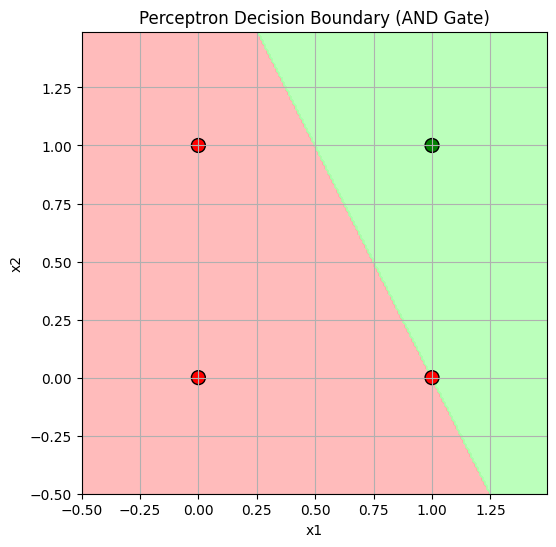

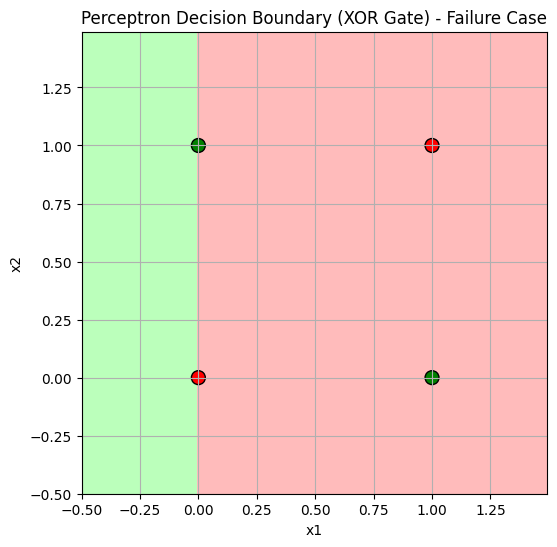

In [ ]:
# AND Gate
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])
p_and = Perceptron(input_size=2)
p_and.train(X_and, y_and)
plot_decision_boundary(p_and, X_and, y_and, "Perceptron Decision Boundary (AND Gate)")

# XOR Gate
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([0, 1, 1, 0])
p_xor = Perceptron(input_size=2)
p_xor.train(X_xor, y_xor)
plot_decision_boundary(p_xor, X_xor, y_xor, "Perceptron Decision Boundary (XOR Gate) - Failure Case")


In [ ]:
# so just to show the necessity of layers.....


import numpy as np
import matplotlib.pyplot as plt

# Sigmoid activation and its derivative
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

# Define the neural network class
class SingleLayerNN:
    def __init__(self, input_size, learning_rate=0.1):
        self.weights = np.random.randn(input_size)
        self.bias = 0
        self.lr = learning_rate

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        a = sigmoid(z)
        return a, z

    def train(self, X, y, epochs=1000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for xi, target in zip(X, y):
                # Forward pass
                a, z = self.forward(xi)

                # Compute loss (MSE)
                loss = 0.5 * (target - a)**2
                total_loss += loss

                # Backpropagation
                dz = (a - target) * sigmoid_derivative(z)
                dw = dz * xi
                db = dz

                # Update parameters
                self.weights -= self.lr * dw
                self.bias -= self.lr * db

            losses.append(total_loss / len(X))
        return losses

    def predict(self, X):
        return np.array([1 if self.forward(x)[0] >= 0.5 else 0 for x in X])


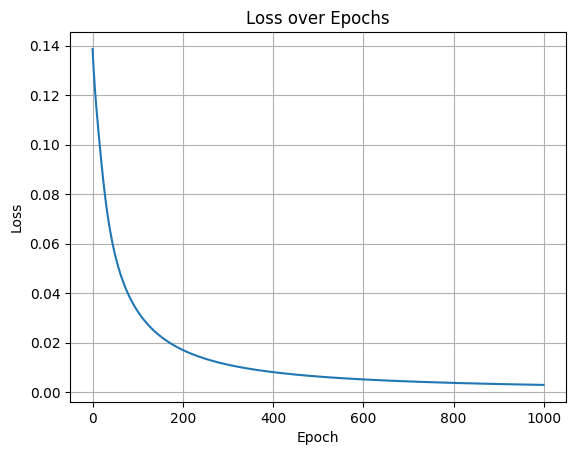

Predictions:
Input: [0 0], Predicted: 0.0008, Class: 0
Input: [0 1], Predicted: 0.0816, Class: 0
Input: [1 0], Predicted: 0.0819, Class: 0
Input: [1 1], Predicted: 0.9036, Class: 1


In [ ]:
# AND gate data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

# X = np.array([[0,0], [0,1], [1,0], [1,1]])
# y = np.array([0, 1, 1, 0])

# Train model
nn = SingleLayerNN(input_size=2, learning_rate=0.5)
losses = nn.train(X, y, epochs=1000)

# Plot loss curve
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Test predictions
print("Predictions:")
for x in X:
    print(f"Input: {x}, Predicted: {nn.forward(x)[0]:.4f}, Class: {nn.predict([x])[0]}")


1. No Hidden Layer
The XOR function is not linearly separable — you cannot draw a straight line to separate the outputs 1 and 0 in its input space. Even though we're using a smoother activation function like sigmoid, we're still using just one neuron, which computes:

This is still equivalent to a linear decision boundary followed by a non-linear squashing function — not sufficient to create non-linear splits required by XOR.

2. Gradient Descent Won’t Fix This
Gradient descent helps optimize weights smoothly, but if the model architecture is too limited, no amount of training will help.

The model will try its best to find a compromise — but you’ll notice:

Predictions are close to 0.5 for the ambiguous (1,1) or (0,0) cases.



# Input (2) → Hidden Layer (2 neurons, sigmoid) → Output Layer (1 neuron, sigmoid)

In [ ]:
Input:
𝑥1,𝑥2

Hidden Layer: 2 nodes with sigmoid

Output: 1 node with sigmoid

Loss: Mean Squared Error (for now)

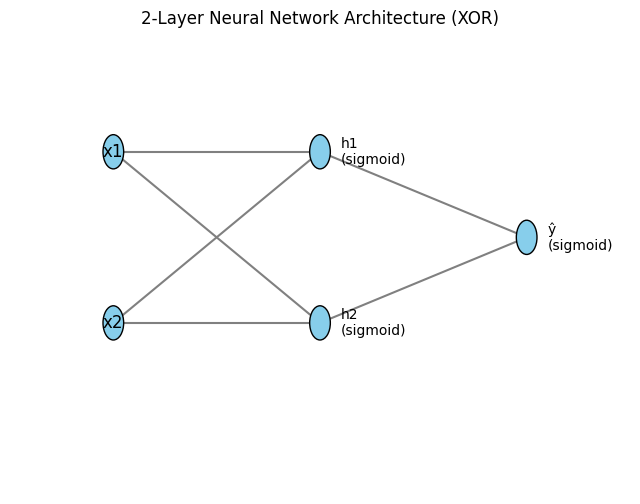

In [ ]:
import matplotlib.pyplot as plt

def draw_2layer_nn():
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis('off')

    # Layer coordinates
    layer_sizes = [2, 2, 1]
    layer_x = [0, 2, 4]
    neuron_y = [[1.5, 0.5], [1.5, 0.5], [1.0]]

    # Draw neurons
    for l_idx, (x, y_coords) in enumerate(zip(layer_x, neuron_y)):
        for y in y_coords:
            circle = plt.Circle((x, y), 0.1, color='skyblue', ec='black', zorder=3)
            ax.add_patch(circle)

    # Add labels
    ax.text(-0.1, 1.5, 'x1', fontsize=12, va='center')
    ax.text(-0.1, 0.5, 'x2', fontsize=12, va='center')
    ax.text(2.2, 1.5, 'h1\n(sigmoid)', fontsize=10, va='center')
    ax.text(2.2, 0.5, 'h2\n(sigmoid)', fontsize=10, va='center')
    ax.text(4.2, 1.0, 'ŷ\n(sigmoid)', fontsize=10, va='center')

    # Draw connections
    for i, y0 in enumerate(neuron_y[0]):         # Input to hidden
        for j, y1 in enumerate(neuron_y[1]):
            ax.plot([layer_x[0], layer_x[1]], [y0, y1], 'gray')

    for i, y0 in enumerate(neuron_y[1]):         # Hidden to output
        for y1 in neuron_y[2]:
            ax.plot([layer_x[1], layer_x[2]], [y0, y1], 'gray')

    ax.set_xlim(-1, 5)
    ax.set_ylim(-0.5, 2.2)
    plt.title("2-Layer Neural Network Architecture (XOR)")
    plt.show()

# Call the function
draw_2layer_nn()


In [ ]:
import numpy as np

# Sigmoid and derivative
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# XOR 2-layer Neural Network
class TwoLayerNN:
    def __init__(self, input_size=2, hidden_size=2, learning_rate=0.1):
        # Initialize weights
        self.W1 = np.random.randn(hidden_size, input_size)  # Hidden layer weights
        self.b1 = np.zeros(hidden_size)                     # Hidden layer bias
        self.W2 = np.random.randn(1, hidden_size)           # Output layer weights
        self.b2 = np.zeros(1)                               # Output layer bias
        self.lr = learning_rate

    def forward(self, x):
        # Forward pass
        self.z1 = np.dot(self.W1, x) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, x, y):
        # Output layer error
        error_output = self.a2 - y
        delta_output = error_output * sigmoid_derivative(self.z2)

        # Hidden layer error
        error_hidden = np.dot(self.W2.T, delta_output)
        delta_hidden = error_hidden * sigmoid_derivative(self.z1)

        # Gradients for output layer
        dW2 = delta_output * self.a1
        db2 = delta_output

        # Gradients for hidden layer
        dW1 = np.outer(delta_hidden, x)
        db1 = delta_hidden

        # Update weights and biases
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1

    def train(self, X, y, epochs=10000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for xi, target in zip(X, y):
                output = self.forward(xi)
                loss = 0.5 * (target - output)**2
                total_loss += loss
                self.backward(xi, target)
            losses.append(total_loss.mean())
        return losses

    def predict(self, X):
        return [1 if self.forward(x) >= 0.5 else 0 for x in X]


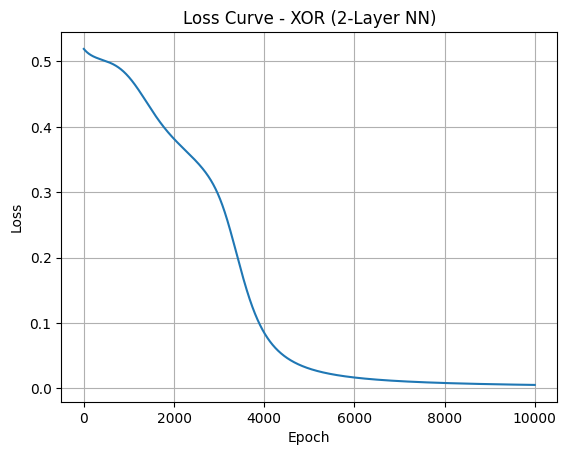

Predictions:
Input: [0 0], Predicted Prob: 0.0450, Class: 0
Input: [0 1], Predicted Prob: 0.9462, Class: 1
Input: [1 0], Predicted Prob: 0.9459, Class: 1
Input: [1 1], Predicted Prob: 0.0539, Class: 0


In [ ]:
import matplotlib.pyplot as plt

# XOR data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

# Train
nn = TwoLayerNN()
losses = nn.train(X, y, epochs=10000)

# Plot loss curve
plt.plot(losses)
plt.title("Loss Curve - XOR (2-Layer NN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Predictions
print("Predictions:")
for x in X:
    prob = nn.forward(x)[0]
    pred = nn.predict([x])[0]
    print(f"Input: {x}, Predicted Prob: {prob:.4f}, Class: {pred}")


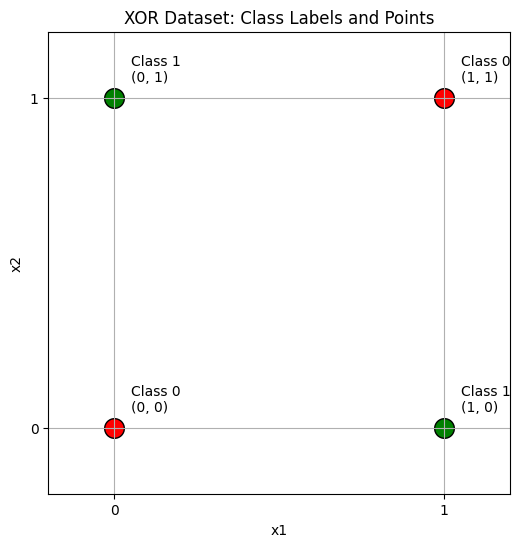

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# XOR data
# X = np.array([[0,0], [0,1], [1,0], [1,1]])
# y = np.array([0, 1, 1, 0])  # XOR outputs

# Plot the XOR dataset with labels and colors
def plot_xor_data(X, y):
    cmap = ListedColormap(['red', 'green'])

    plt.figure(figsize=(6, 6))
    for i, point in enumerate(X):
        label = 'Class 0' if y[i] == 0 else 'Class 1'
        color = 'red' if y[i] == 0 else 'green'
        plt.scatter(point[0], point[1], c=color, s=200, edgecolors='k')
        plt.text(point[0] + 0.05, point[1] + 0.05, f"{label}\n({point[0]}, {point[1]})", fontsize=10)

    plt.title("XOR Dataset: Class Labels and Points")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xticks([0, 1])
    plt.yticks([0, 1])
    plt.grid(True)
    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# Call the function
plot_xor_data(X, y)


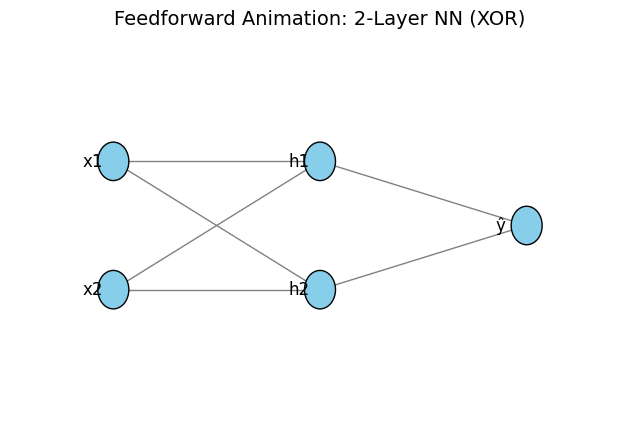

In [ ]:
# jsut an animation way
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# Neuron positions
input_coords = [(0, 1.5), (0, 0.5)]         # x1, x2
hidden_coords = [(2, 1.5), (2, 0.5)]        # h1, h2
output_coords = [(4, 1.0)]                  # ŷ

# All node positions
nodes = input_coords + hidden_coords + output_coords

# Connections (from_node_index, to_node_index)
connections = [
    (0, 2), (0, 3),  # x1 to h1, h2
    (1, 2), (1, 3),  # x2 to h1, h2
    (2, 4), (3, 4)   # h1, h2 to output
]

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_xlim(-1, 5)
ax.set_ylim(-0.5, 2.5)
ax.axis('off')

# Draw neurons
circles = []
for (x, y) in nodes:
    c = plt.Circle((x, y), 0.15, color='skyblue', ec='black', zorder=3)
    circles.append(c)
    ax.add_patch(c)

# Label neurons
labels = ['x1', 'x2', 'h1', 'h2', 'ŷ']
label_pos = [(x - 0.3, y) for x, y in nodes]
for pos, text in zip(label_pos, labels):
    ax.text(*pos, text, fontsize=12, va='center')

# Initialize connection lines
lines = []
for i, j in connections:
    x1, y1 = nodes[i]
    x2, y2 = nodes[j]
    line, = ax.plot([x1, x2], [y1, y2], color='gray', lw=1)
    lines.append(line)

# Animate activation flow
def animate(i):
    for k, line in enumerate(lines):
        if k == i:
            line.set_color('red')
            line.set_linewidth(3)
        else:
            line.set_color('gray')
            line.set_linewidth(1)

    # Highlight active neurons
    active_nodes = set()
    if i < len(connections):
        from_idx, to_idx = connections[i]
        active_nodes.update([from_idx, to_idx])
    for idx, circle in enumerate(circles):
        if idx in active_nodes:
            circle.set_facecolor('orange')
        else:
            circle.set_facecolor('skyblue')
    return lines + circles

# Create animation
ani = FuncAnimation(fig, animate, frames=len(connections),
                    interval=700, repeat=True)

plt.title("Feedforward Animation: 2-Layer NN (XOR)", fontsize=14)
plt.show()


In [ ]:
ani.save("nn_flow_xor.gif", writer='pillow', fps=1)

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

class ThreeLayerNN:
    def __init__(self, input_size=2, hidden1_size=5, hidden2_size=5, output_size=1, learning_rate=0.1):
        # Initialize weights and biases
        self.W1 = np.random.randn(hidden1_size, input_size)
        self.b1 = np.zeros(hidden1_size)

        self.W2 = np.random.randn(hidden2_size, hidden1_size)
        self.b2 = np.zeros(hidden2_size)

        self.W3 = np.random.randn(output_size, hidden2_size)
        self.b3 = np.zeros(output_size)

        self.lr = learning_rate

    def forward(self, x):
        self.z1 = np.dot(self.W1, x) + self.b1
        self.a1 = sigmoid(self.z1)

        self.z2 = np.dot(self.W2, self.a1) + self.b2
        self.a2 = sigmoid(self.z2)

        self.z3 = np.dot(self.W3, self.a2) + self.b3
        self.a3 = sigmoid(self.z3)

        return self.a3

    def backward(self, x, y):
        # Output layer error
        delta3 = (self.a3 - y) * sigmoid_derivative(self.z3)

        # Hidden layer 2 error
        delta2 = np.dot(self.W3.T, delta3) * sigmoid_derivative(self.z2)

        # Hidden layer 1 error
        delta1 = np.dot(self.W2.T, delta2) * sigmoid_derivative(self.z1)

        # Gradients and updates
        self.W3 -= self.lr * np.outer(delta3, self.a2)
        self.b3 -= self.lr * delta3

        self.W2 -= self.lr * np.outer(delta2, self.a1)
        self.b2 -= self.lr * delta2

        self.W1 -= self.lr * np.outer(delta1, x)
        self.b1 -= self.lr * delta1

    def train(self, X, y, epochs=10000):
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for xi, yi in zip(X, y):
                output = self.forward(xi)
                loss = 0.5 * (output - yi)**2
                total_loss += loss
                self.backward(xi, yi)
            losses.append(total_loss.mean())
        return losses

    def predict(self, X):
        return [1 if self.forward(xi) >= 0.5 else 0 for xi in X]
        # Visualizations
    def get_activations(self, X):
        activations_layer1 = []
        activations_layer2 = []

        for xi in X:
            z1 = np.dot(self.W1, xi) + self.b1
            a1 = sigmoid(z1)

            z2 = np.dot(self.W2, a1) + self.b2
            a2 = sigmoid(z2)

            activations_layer1.append(a1)
            activations_layer2.append(a2)

        return np.array(activations_layer1), np.array(activations_layer2)


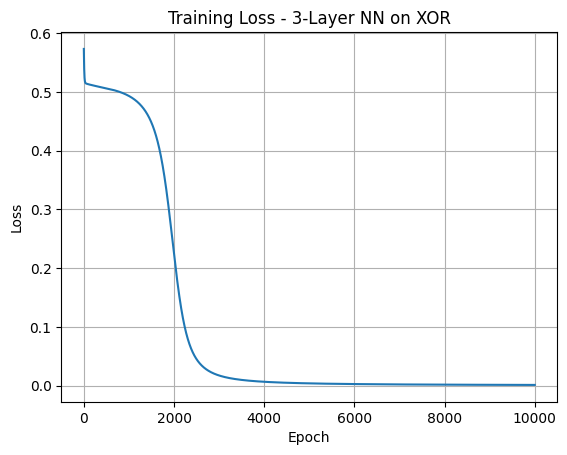

Predictions:
Input: [0 0], Predicted Prob: 0.0228, Class: 0
Input: [0 1], Predicted Prob: 0.9780, Class: 1
Input: [1 0], Predicted Prob: 0.9754, Class: 1
Input: [1 1], Predicted Prob: 0.0226, Class: 0


In [ ]:
import matplotlib.pyplot as plt

# XOR data
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 1, 1, 0])

# Train model
model = ThreeLayerNN()
losses = model.train(X, y, epochs=10000)

# Plot loss
plt.plot(losses)
plt.title("Training Loss - 3-Layer NN on XOR")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Predictions
print("Predictions:")
for xi in X:
    prob = model.forward(xi)[0]
    print(f"Input: {xi}, Predicted Prob: {prob:.4f}, Class: {1 if prob >= 0.5 else 0}")


In [ ]:
# lets see some visualization of how the input feature space is

In [ ]:
from sklearn.decomposition import PCA
# pip3 install scikit-learn
def plot_layer_activations(X, y, activations, title):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(activations)

    plt.figure(figsize=(6, 6))
    for label in np.unique(y):
        idxs = np.where(y == label)
        plt.scatter(reduced[idxs, 0], reduced[idxs, 1], label=f"Class {label}", s=100)

    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.grid(True)
    plt.legend()
    plt.show()


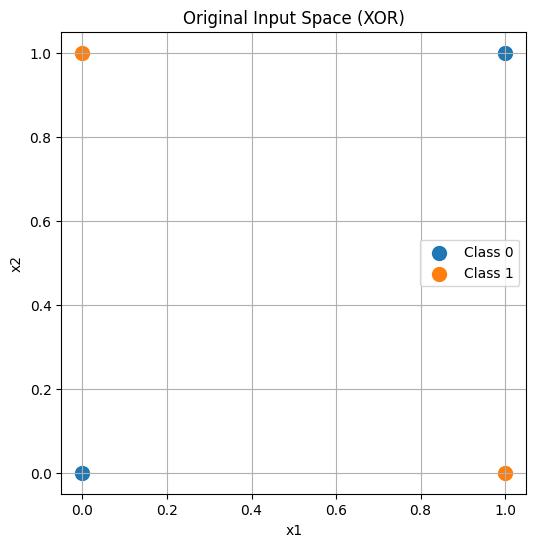

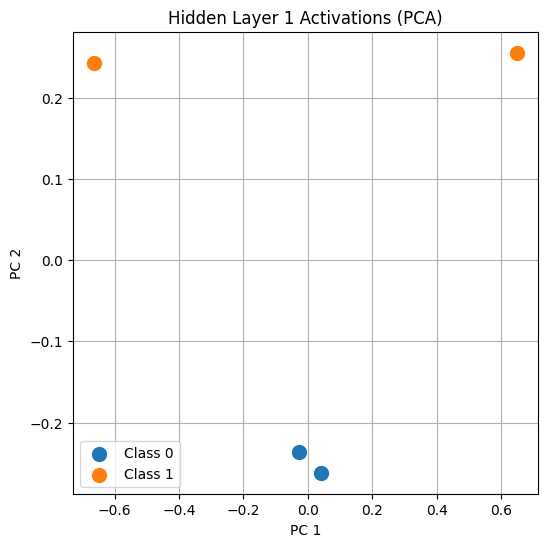

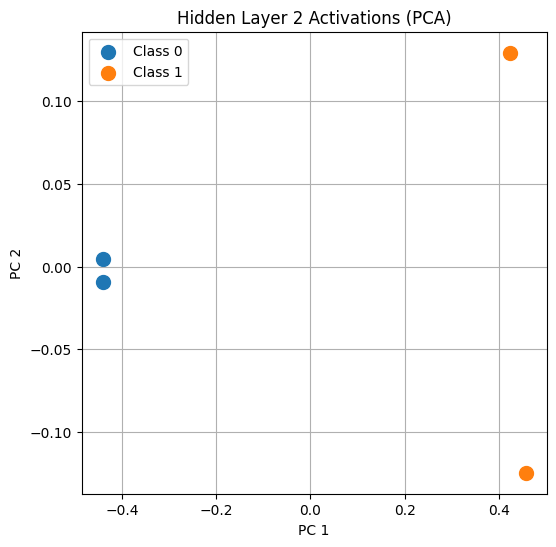

In [ ]:
# Get activations
act1, act2 = model.get_activations(X)

# Plot input space (original XOR)
plt.figure(figsize=(6,6))
for label in np.unique(y):
    idx = np.where(y == label)
    plt.scatter(X[idx, 0], X[idx, 1], label=f"Class {label}", s=100)
plt.title("Original Input Space (XOR)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Plot hidden layer 1 activations
plot_layer_activations(X, y, act1, "Hidden Layer 1 Activations (PCA)")

# Plot hidden layer 2 activations
plot_layer_activations(X, y, act2, "Hidden Layer 2 Activations (PCA)")


In [ ]:
Input Layer:         x1, x2      → 2 inputs
Hidden Layer:        h1, h2      → 2 neurons, sigmoid
Output Layer:        ŷ          → 1 neuron, sigmoid


Forward Propagation: how input moves through the network to produce output
Backward Propagation: how the error is used to update weights

In [ ]:
# if someone wants to see
import numpy as np

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

def forward_backward_demo(x, y, learning_rate=0.1):
    print("==== INITIALIZATION ====")

    # Weights and biases
    W1 = np.array([[0.5, -0.4],
                   [0.3,  0.8]])   # shape (2, 2)
    b1 = np.array([0.0, 0.0])      # shape (2,)
    W2 = np.array([[0.7, -1.2]])   # shape (1, 2)
    b2 = np.array([0.0])           # shape (1,)

    print(f"x = {x}, y = {y}")
    print(f"W1 =\n{W1}")
    print(f"b1 = {b1}")
    print(f"W2 = {W2}")
    print(f"b2 = {b2}")

    # === Forward Propagation ===
    print("\n==== FORWARD PROPAGATION ====")
    z1 = W1 @ x + b1               # shape (2,)
    a1 = sigmoid(z1)               # shape (2,)
    print(f"z1 = {z1}")
    print(f"a1 = {a1}")

    z2 = W2 @ a1 + b2              # shape (1,)
    y_hat = sigmoid(z2)[0]        # scalar output
    print(f"z2 = {z2}")
    print(f"ŷ = {y_hat}")

    # Loss (MSE)
    loss = 0.5 * (y_hat - y) ** 2
    print(f"Loss = {loss}")

    # === Backward Propagation ===
    print("\n==== BACKWARD PROPAGATION ====")

    # Output layer gradient
    dL_dy_hat = y_hat - y
    dy_hat_dz2 = sigmoid_derivative(z2)[0]
    dz2 = dL_dy_hat * dy_hat_dz2  # scalar

    dW2 = dz2 * a1.reshape(1, -1)  # shape (1, 2)
    db2 = dz2                     # scalar
    print(f"dW2 = {dW2}")
    print(f"db2 = {db2}")

    # Hidden layer gradient
    dz1 = (W2.T * dz2).flatten() * sigmoid_derivative(z1)  # shape (2,)
    dW1 = dz1.reshape(-1, 1) @ x.reshape(1, -1)             # shape (2, 2)
    db1 = dz1
    print(f"dW1 =\n{dW1}")
    print(f"db1 = {db1}")

    # === Weight Updates ===
    print("\n==== WEIGHT UPDATES ====")
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    print(f"Updated W2 = {W2}")
    print(f"Updated b2 = {b2}")
    print(f"Updated W1 =\n{W1}")
    print(f"Updated b1 = {b1}")

# Run it with a single XOR input sample
x_sample = np.array([1, 0])
y_sample = 1
forward_backward_demo(x_sample, y_sample)


==== INITIALIZATION ====
x = [1 0], y = 1
W1 =
[[ 0.5 -0.4]
 [ 0.3  0.8]]
b1 = [0. 0.]
W2 = [[ 0.7 -1.2]]
b2 = [0.]

==== FORWARD PROPAGATION ====
z1 = [0.5 0.3]
a1 = [0.62245933 0.57444252]
z2 = [-0.25360949]
ŷ = 0.4369352813172148
Loss = 0.158520938712662

==== BACKWARD PROPAGATION ====
dW2 = [[-0.08622729 -0.07957567]]
db2 = -0.13852678190217188
dW1 =
[[-0.02278802  0.        ]
 [ 0.04063683  0.        ]]
db1 = [-0.02278802  0.04063683]

==== WEIGHT UPDATES ====
Updated W2 = [[ 0.70862273 -1.19204243]]
Updated b2 = [0.01385268]
Updated W1 =
[[ 0.5022788  -0.4       ]
 [ 0.29593632  0.8       ]]
Updated b1 = [ 0.0022788  -0.00406368]


In [ ]:
# a bit simpler

def backpropagation_steps():
    print("==== BACKPROPAGATION DEMO (Conceptual) ====")

    # Step 1: Define network structure
    print("\n[STEP 1] Network Structure")
    print(" - Input Layer: x1, x2")
    print(" - Hidden Layer: h1, h2 (with sigmoid activation)")
    print(" - Output Layer: ŷ (with sigmoid activation)")

    # Step 2: Forward propagation symbolic expressions
    print("\n[STEP 2] Forward Pass Equations")
    print(" - z1_h1 = w11 * x1 + w12 * x2 + b1_1")
    print(" - a1_h1 = sigmoid(z1_h1)")
    print(" - z1_h2 = w21 * x1 + w22 * x2 + b1_2")
    print(" - a1_h2 = sigmoid(z1_h2)")
    print(" - z2 = w31 * a1_h1 + w32 * a1_h2 + b2")
    print(" - ŷ = sigmoid(z2)")

    # Step 3: Loss function
    print("\n[STEP 3] Loss Function")
    print(" - L = 0.5 * (ŷ - y)^2  (Mean Squared Error)")

    # Step 4: Backpropagation - Output layer
    print("\n[STEP 4] Backpropagation: Output Layer")
    print(" - dL/dŷ = (ŷ - y)")
    print(" - dŷ/dz2 = sigmoid(z2) * (1 - sigmoid(z2))")
    print(" - δ2 = dL/dz2 = (ŷ - y) * sigmoid'(z2)")
    print(" - dL/dw31 = δ2 * a1_h1")
    print(" - dL/dw32 = δ2 * a1_h2")
    print(" - dL/db2  = δ2")

    # Step 5: Backpropagation - Hidden layer
    print("\n[STEP 5] Backpropagation: Hidden Layer")
    print(" - dz2/da1_h1 = w31, dz2/da1_h2 = w32")
    print(" - da1/dz1 = sigmoid(z1) * (1 - sigmoid(z1))")
    print(" - δ1_h1 = δ2 * w31 * sigmoid'(z1_h1)")
    print(" - δ1_h2 = δ2 * w32 * sigmoid'(z1_h2)")
    print(" - dL/dw11 = δ1_h1 * x1")
    print(" - dL/dw12 = δ1_h1 * x2")
    print(" - dL/dw21 = δ1_h2 * x1")
    print(" - dL/dw22 = δ1_h2 * x2")
    print(" - dL/db1_1 = δ1_h1")
    print(" - dL/db1_2 = δ1_h2")

    # Step 6: Update rules
    print("\n[STEP 6] Gradient Descent Weight Updates")
    print(" - w_new = w_old - learning_rate * dL/dw")
    print(" - b_new = b_old - learning_rate * dL/db")

    print("Just a way to show this")


backpropagation_steps()


==== BACKPROPAGATION DEMO (Conceptual) ====

[STEP 1] Network Structure
 - Input Layer: x1, x2
 - Hidden Layer: h1, h2 (with sigmoid activation)
 - Output Layer: ŷ (with sigmoid activation)

[STEP 2] Forward Pass Equations
 - z1_h1 = w11 * x1 + w12 * x2 + b1_1
 - a1_h1 = sigmoid(z1_h1)
 - z1_h2 = w21 * x1 + w22 * x2 + b1_2
 - a1_h2 = sigmoid(z1_h2)
 - z2 = w31 * a1_h1 + w32 * a1_h2 + b2
 - ŷ = sigmoid(z2)

[STEP 3] Loss Function
 - L = 0.5 * (ŷ - y)^2  (Mean Squared Error)

[STEP 4] Backpropagation: Output Layer
 - dL/dŷ = (ŷ - y)
 - dŷ/dz2 = sigmoid(z2) * (1 - sigmoid(z2))
 - δ2 = dL/dz2 = (ŷ - y) * sigmoid'(z2)
 - dL/dw31 = δ2 * a1_h1
 - dL/dw32 = δ2 * a1_h2
 - dL/db2  = δ2

[STEP 5] Backpropagation: Hidden Layer
 - dz2/da1_h1 = w31, dz2/da1_h2 = w32
 - da1/dz1 = sigmoid(z1) * (1 - sigmoid(z1))
 - δ1_h1 = δ2 * w31 * sigmoid'(z1_h1)
 - δ1_h2 = δ2 * w32 * sigmoid'(z1_h2)
 - dL/dw11 = δ1_h1 * x1
 - dL/dw12 = δ1_h1 * x2
 - dL/dw21 = δ1_h2 * x1
 - dL/dw22 = δ1_h2 * x2
 - dL/db1_1 =

In [ ]:
# !which python
# !pip show seaborn

# This ensures you're installing into ABM
-m pip install seaborn


SyntaxError: invalid syntax (1616193957.py, line 5)

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       0.95      1.00      0.97        35
           3       0.97      0.97      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



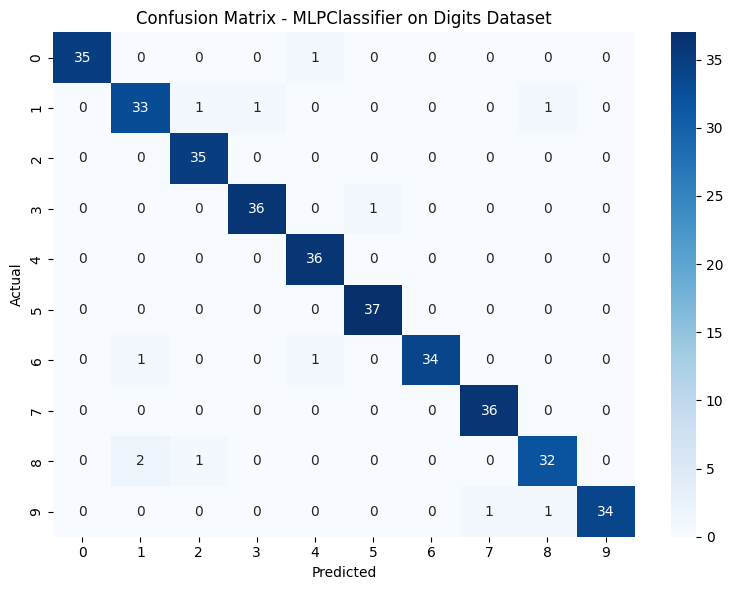

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load MNIST-like dataset (8x8 images, smaller version)
digits = load_digits()
X, y = digits.data, digits.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the model
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred = mlp.predict(X_test_scaled)

# Print evaluation metrics
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_mat, annot=True, cmap='Blues', fmt='d',
            xticklabels=digits.target_names,
            yticklabels=digits.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLPClassifier on Digits Dataset")
plt.tight_layout()
plt.show()




                  Model  Accuracy
0   Logistic Regression  0.982456
5      SVM (RBF Kernel)  0.982456
6  Neural Network (MLP)  0.964912
2                   KNN  0.956140
4         Random Forest  0.956140
3           Naive Bayes  0.929825
1         Decision Tree  0.903509


/var/folders/rq/_81fzkgd4ys00__g48b4lls00000gn/T/ipykernel_4189/2180742187.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Accuracy", y="Model", palette="viridis")


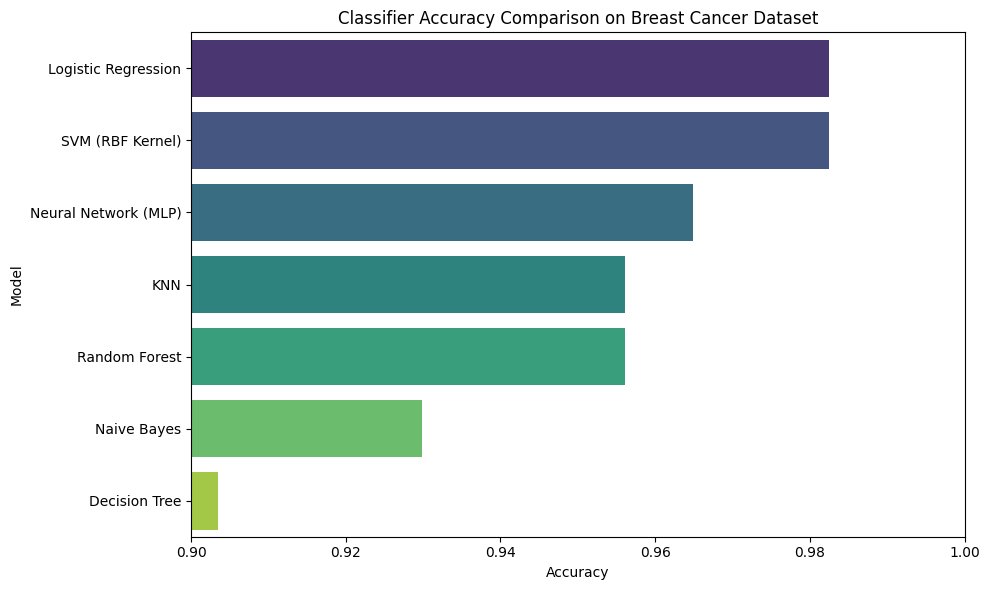

In [ ]:
# comparsion

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM (RBF Kernel)": SVC(),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# Show comparison
df_results = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
df_results = df_results.sort_values(by="Accuracy", ascending=False)
print(df_results)

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="Accuracy", y="Model", palette="viridis")
plt.title("Classifier Accuracy Comparison on Breast Cancer Dataset")
plt.xlim(0.9, 1.0)
plt.tight_layout()
plt.show()


/var/folders/rq/_81fzkgd4ys00__g48b4lls00000gn/T/ipykernel_4189/3572973654.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x="Accuracy", y="Model", palette="Set2")


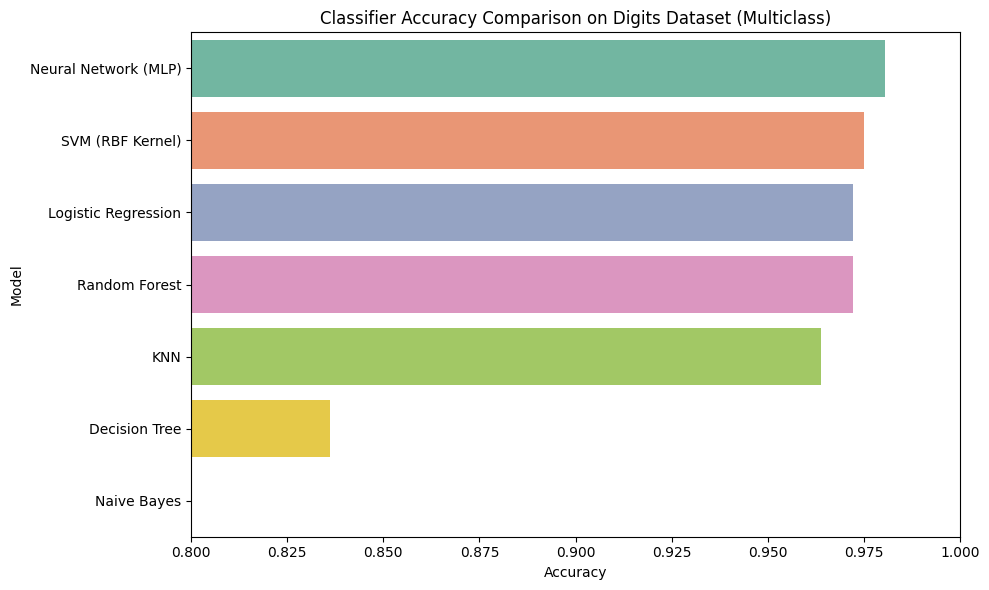

                  Model  Accuracy
6  Neural Network (MLP)  0.980556
5      SVM (RBF Kernel)  0.975000
0   Logistic Regression  0.972222
4         Random Forest  0.972222
2                   KNN  0.963889
1         Decision Tree  0.836111
3           Naive Bayes  0.741667


In [ ]:
# multiclass dataset

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(),
    "SVM (RBF Kernel)": SVC(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=1000, random_state=42)
}

# Train and evaluate
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

# Create DataFrame and visualize
df_results = pd.DataFrame(results.items(), columns=["Model", "Accuracy"]).sort_values(by="Accuracy", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x="Accuracy", y="Model", palette="Set2")
plt.title("Classifier Accuracy Comparison on Digits Dataset (Multiclass)")
plt.xlim(0.8, 1.0)
plt.tight_layout()
plt.show()

print(df_results)


   Hidden Layers  Learning Rate  Test Accuracy
0          (32,)          0.001       0.980556
1          (64,)          0.001       0.980556
2       (64, 32)          0.001       0.966667
3       (64, 32)          0.010       0.958333
4  (128, 64, 32)          0.001       0.977778
5  (128, 64, 32)          0.010       0.969444


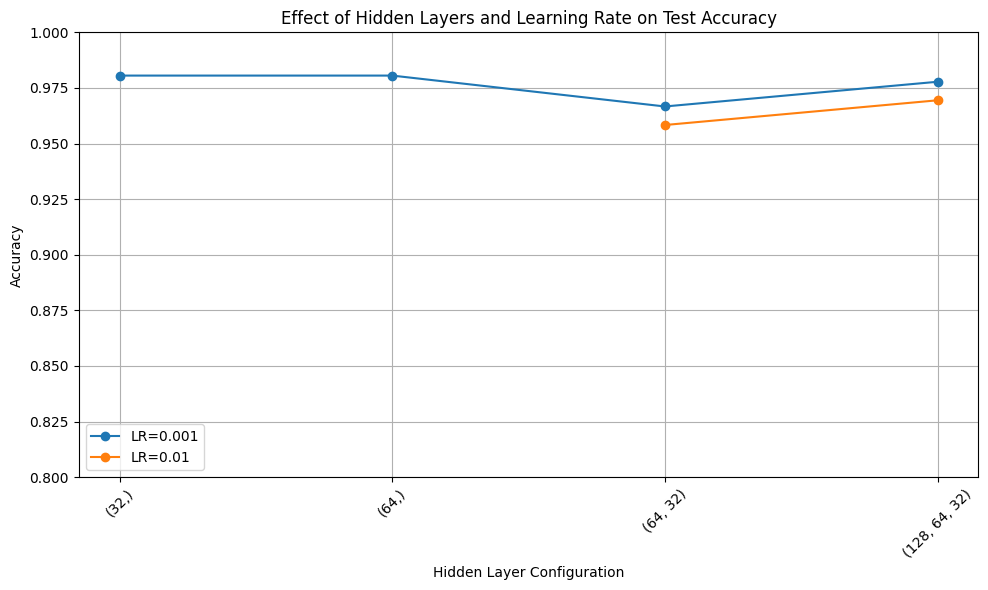

In [ ]:
# A bit on Hyper parameter selection
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split and scale
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

configs = [
    {"hidden_layer_sizes": (32,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64, 32), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64, 32), "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (128, 64, 32), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (128, 64, 32), "learning_rate_init": 0.01},
]


# (32,) → 1 hidden layer with 32 nodes
# (64,) → 1 hidden layer with 64 nodes
# (64, 32) → 2 hidden layers, first with 64 nodes, second with 32 nodes
# (128, 64, 32) → 3 hidden layers, with 128, 64, and 32 nodes respectively

results = []

for config in configs:
    model = MLPClassifier(hidden_layer_sizes=config["hidden_layer_sizes"],
                          learning_rate_init=config["learning_rate_init"],
                          max_iter=300, random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    results.append({
        "Hidden Layers": str(config["hidden_layer_sizes"]),
        "Learning Rate": config["learning_rate_init"],
        "Test Accuracy": acc
    })

# Results as DataFrame
df_results = pd.DataFrame(results)
print(df_results)

# Plot results
plt.figure(figsize=(10, 6))
for lr in df_results["Learning Rate"].unique():
    subset = df_results[df_results["Learning Rate"] == lr]
    plt.plot(subset["Hidden Layers"], subset["Test Accuracy"], marker='o', label=f"LR={lr}")

plt.title("Effect of Hidden Layers and Learning Rate on Test Accuracy")
plt.xlabel("Hidden Layer Configuration")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# a comparsion across training time, learning rate, loss, epochs

              Configuration  Test Accuracy  Training Time (s)
0          (32,) | LR=0.001       0.980556           0.703084
1          (64,) | LR=0.001       0.980556           0.671173
4  (128, 64, 32) | LR=0.001       0.977778           0.779475
5   (128, 64, 32) | LR=0.01       0.969444           0.381845
2       (64, 32) | LR=0.001       0.966667           0.681144
3        (64, 32) | LR=0.01       0.958333           0.176995


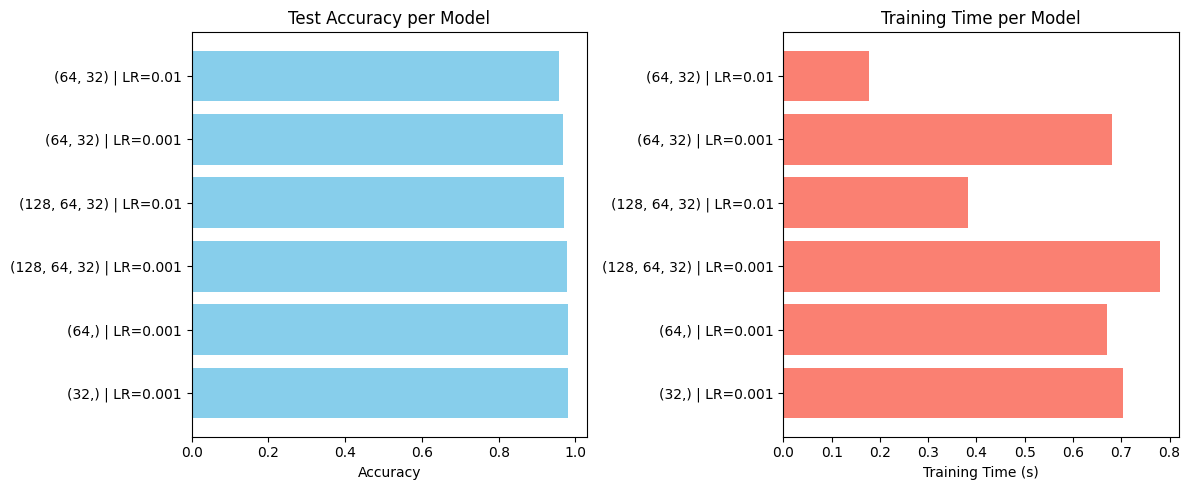

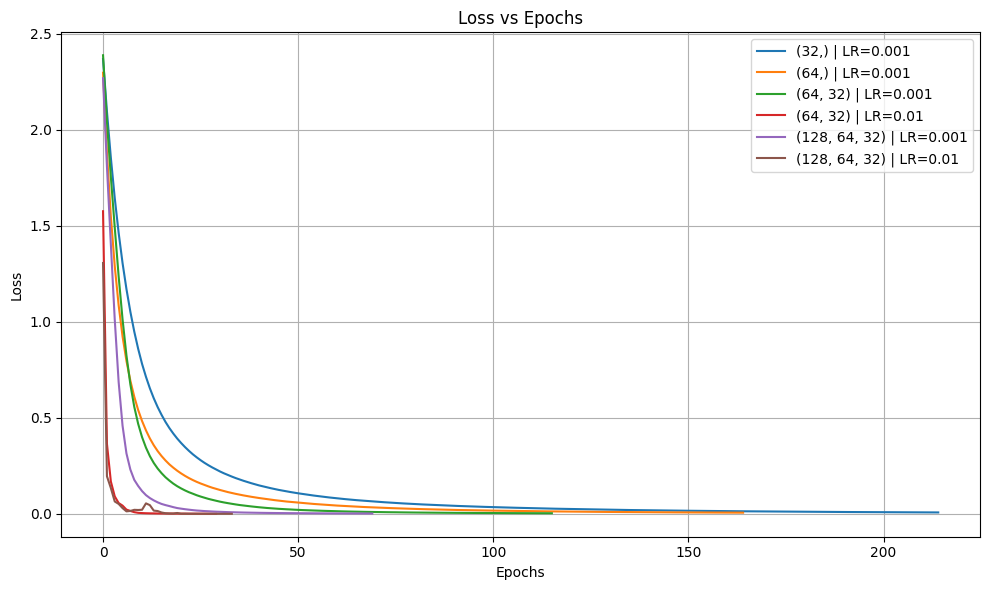

In [ ]:
import time
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt
import pandas as pd

# Load digits dataset
digits = load_digits()
X, y = digits.data, digits.target

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Configurations
configs = [
    {"hidden_layer_sizes": (32,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64,), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64, 32), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (64, 32), "learning_rate_init": 0.01},
    {"hidden_layer_sizes": (128, 64, 32), "learning_rate_init": 0.001},
    {"hidden_layer_sizes": (128, 64, 32), "learning_rate_init": 0.01},
]

results = []
loss_curves = {}

# Loop through configurations
for cfg in configs:
    model = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        learning_rate_init=cfg["learning_rate_init"],
        max_iter=300,
        random_state=42,
        verbose=False
    )
    start = time.time()
    model.fit(X_train_scaled, y_train)
    end = time.time()

    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    duration = end - start
    label = f"{cfg['hidden_layer_sizes']} | LR={cfg['learning_rate_init']}"

    results.append({
        "Configuration": label,
        "Test Accuracy": acc,
        "Training Time (s)": duration
    })
    loss_curves[label] = model.loss_curve_

# DataFrame summary
df = pd.DataFrame(results).sort_values(by="Test Accuracy", ascending=False)
print(df)

# Plot Accuracy and Training Time
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.barh(df["Configuration"], df["Test Accuracy"], color='skyblue')
plt.xlabel("Accuracy")
plt.title("Test Accuracy per Model")

plt.subplot(1, 2, 2)
plt.barh(df["Configuration"], df["Training Time (s)"], color='salmon')
plt.xlabel("Training Time (s)")
plt.title("Training Time per Model")
plt.tight_layout()
plt.show()

# Plot Loss Curves
plt.figure(figsize=(10, 6))
for label, curve in loss_curves.items():
    plt.plot(curve, label=label)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.10486&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false
